In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def get_subsys_masks(channel_names):    
    # Create boolean masks for each subsystem
    subsys_counts = {}
    subsys_masks = {}
    n = len(channel_names)
    for i, name in enumerate(channel_names):
        key = name[3:6]

        subsys_counts[key] = subsys_counts.get(key, 0) + 1

        if key not in subsys_masks:
            subsys_masks[key] = np.zeros(n, dtype=bool)
        subsys_masks[key][i] = True
    return subsys_masks

# Load true values and channel names
gt = pd.read_parquet('../data/GW/test_stand_CTWS.parquet')
channel_names = list(gt.keys())
subsys_masks = get_subsys_masks(channel_names)

In [ ]:
# Load data
values = torch.load('values/GWIMC_100s_k15.pt', map_location='cpu')
preds = values[0]
ground_truth = values[1]

# Get same dataset as the model -- Used for channel names
gtSUB = gt.iloc[:,subsys_masks['IMC']]  

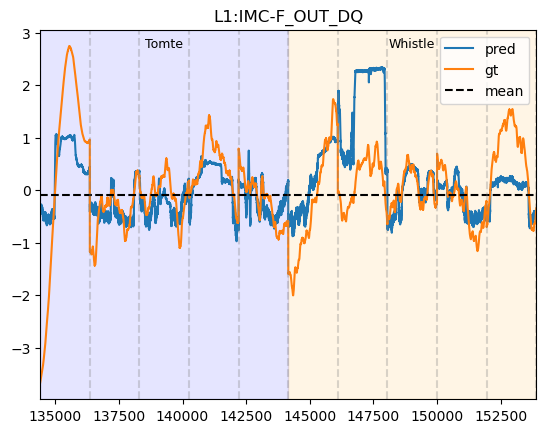

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

id = 8
mean = torch.mean(ground_truth[:, id].cpu()).item()
segment_len = ground_truth.shape[0]/4 # Length of each class

step_size = int(segment_len / 37) # Length of each sample within each class
data_middle = int(2*segment_len) # Position in the series where to center the image. Data order = [Normal, Tomte, Whistle, Scattered Light]
show_len = int(1948*5) # Interval to plot around data_middle
show_step_lines = True # Decision if you want to show start and end points of the samples

if data_middle == None:
    show_step_lines = False
# --- convert to numpy ---
pred_vals = preds[:, id].detach().cpu().numpy()
gt_vals = ground_truth[:, id].detach().cpu().numpy()

# --- slicing logic ---
if data_middle is None:
    x = np.arange(len(pred_vals))
    pred_plot = pred_vals.copy()
    gt_plot = gt_vals.copy()
else:
    start = data_middle - show_len
    end = data_middle + show_len

    x = np.arange(start, end)
    pred_plot = pred_vals[start:end].copy()
    gt_plot = gt_vals[start:end].copy()


plt.figure()

plt.plot(x, pred_plot, label="pred")
plt.plot(x, gt_plot, label="gt")

plt.axhline(y=mean, linestyle="--", label="mean", color="black")

# --- segments ---
segments = [
    ("Normal", 0, segment_len, "green"),
    ("Tomte", segment_len, 2 * segment_len, "blue"),
    ("Whistle", 2 * segment_len, 3 * segment_len, "orange"),
    ("Scat", 3 * segment_len, 4 * segment_len, "red"),
]

if data_middle is not None:
    plt.xlim(start, end)

x_min, x_max = plt.xlim()

for label, seg_start, seg_end, color in segments:
    vis_start = max(seg_start, x_min)
    vis_end = min(seg_end, x_max)

    if vis_start < vis_end:
        plt.axvspan(vis_start, vis_end, alpha=0.1, color=color)

        plt.text((vis_start + vis_end) / 2,
                 plt.ylim()[1] * 0.95,
                 label,
                 ha="center",
                 va="top",
                 fontsize=9)

# --- step lines ---
if show_step_lines:
    start_line = (int(x_min) // step_size) * step_size

    for xi in range(start_line, int(x_max) + step_size, step_size):
        if x_min <= xi <= x_max:
            plt.axvline(x=xi, color="gray", linestyle="--", alpha=0.3)

plt.title(gtSUB.columns[id])
plt.legend()
plt.show()

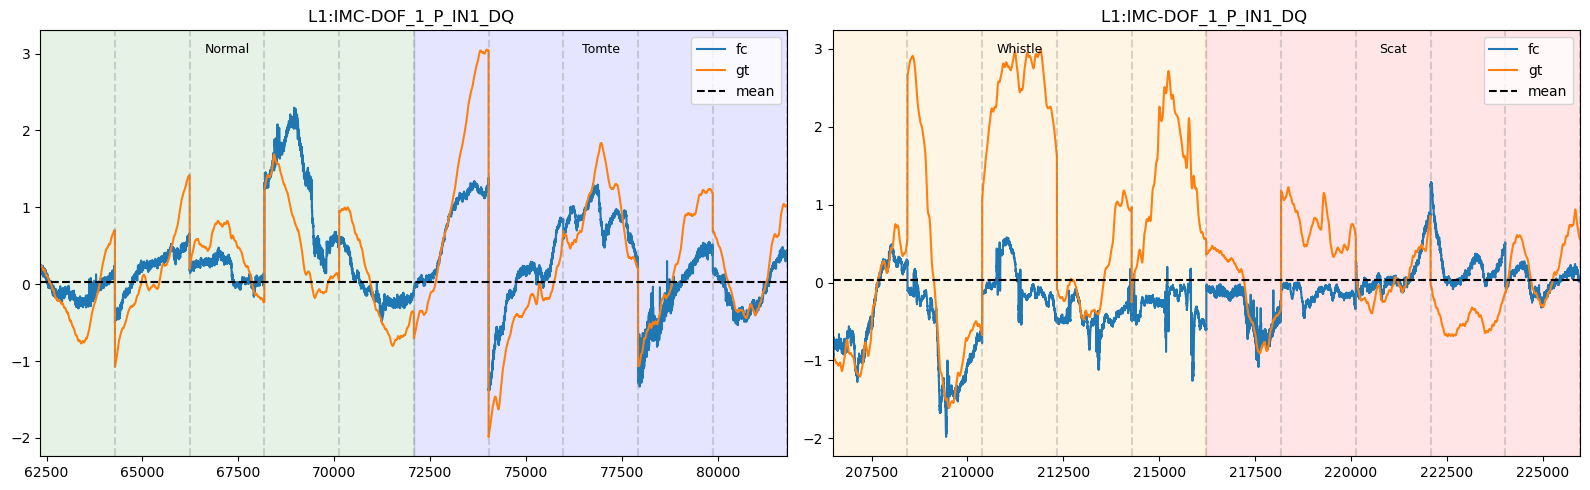

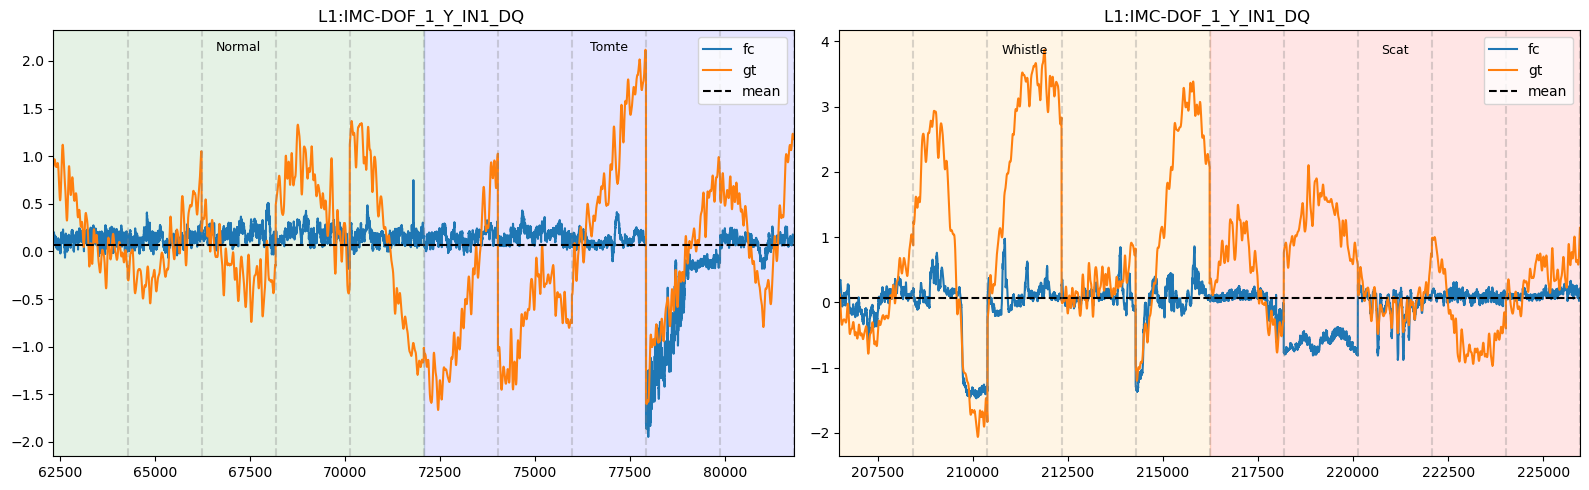

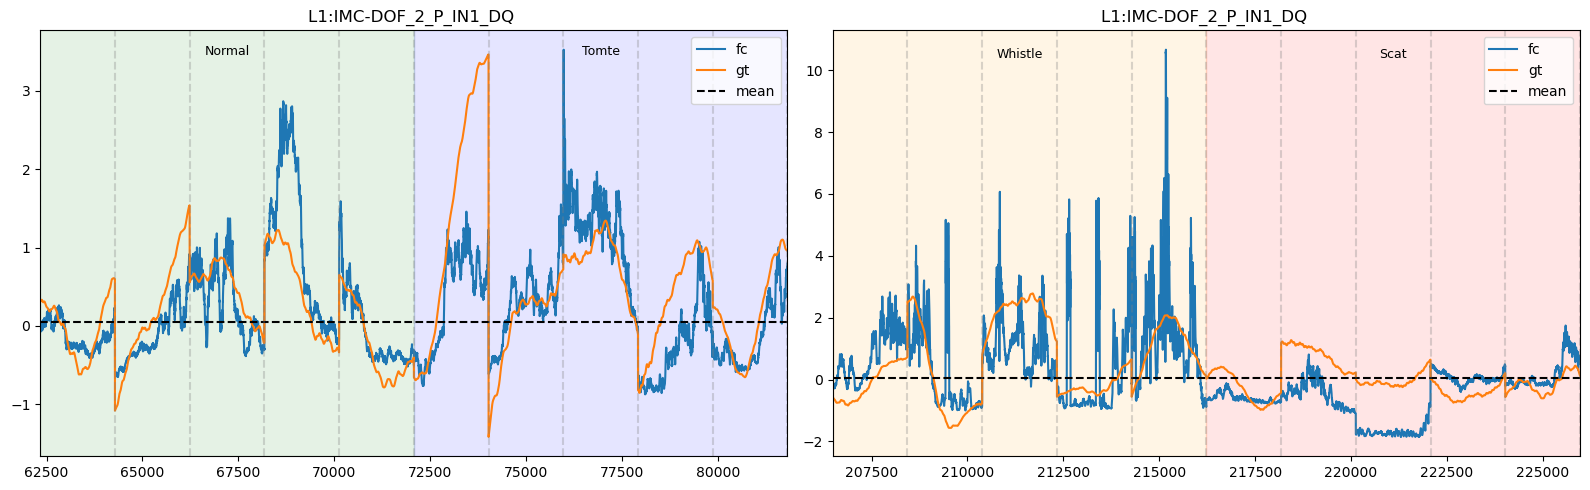

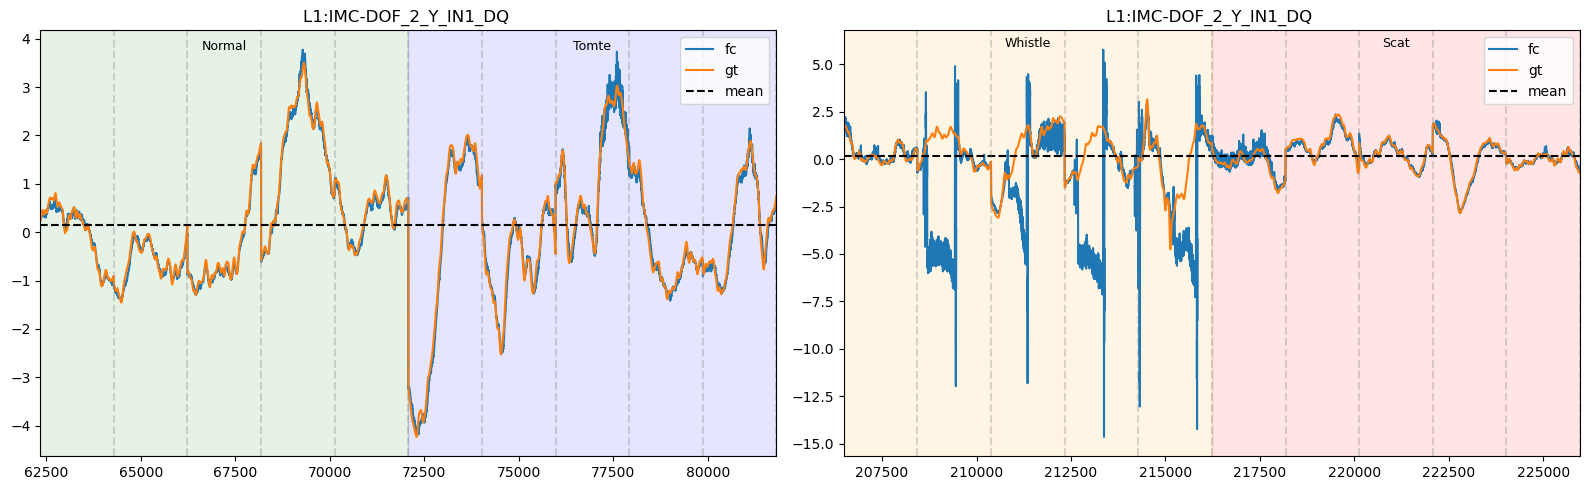

In [ ]:
# Plot multiple channels
for id in range(0, 4):

    mean = torch.mean(ground_truth[:, id].cpu()).item()
    segment_len = ground_truth.shape[0] / 4

    step_size = int(segment_len / 37)
    show_len = int(1948 * 5)
    show_step_lines = True

    # --- convert to numpy ---
    pred_vals = preds[:, id].detach().cpu().numpy()
    gt_vals = ground_truth[:, id].detach().cpu().numpy()

    # --- segments ---
    segments = [
        ("Normal", 0, segment_len, "green"),
        ("Tomte", segment_len, 2 * segment_len, "blue"),
        ("Whistle", 2 * segment_len, 3 * segment_len, "orange"),
        ("Scat", 3 * segment_len, 4 * segment_len, "red"),
    ]

    # helper function
    def draw_plot(ax, data_middle, show_len, id, title_suffix=""):

        start = int(data_middle - show_len)
        end = int(data_middle + show_len)

        x = np.arange(start, end)

        pred_plot = pred_vals[start:end].copy()
        gt_plot = gt_vals[start:end].copy()

        ax.plot(x, pred_plot, label="fc")
        ax.plot(x, gt_plot, label="gt")

        ax.axhline(y=mean, linestyle="--", color="black", label="mean")

        ax.set_xlim(start, end)

        x_min, x_max = ax.get_xlim()

        # --- segment coloring ---
        for label, seg_start, seg_end, color in segments:

            vis_start = max(seg_start, x_min)
            vis_end = min(seg_end, x_max)

            if vis_start < vis_end:
                ax.axvspan(vis_start, vis_end, alpha=0.1, color=color)

                ax.text(
                    (vis_start + vis_end) / 2,
                    ax.get_ylim()[1] * 0.95,
                    label,
                    ha="center",
                    va="top",
                    fontsize=9
                )

        # --- step lines ---
        if show_step_lines:

            start_line = (int(x_min) // step_size) * step_size

            for xi in range(start_line, int(x_max) + step_size, step_size):

                if x_min <= xi <= x_max:
                    ax.axvline(
                        x=xi,
                        color="gray",
                        linestyle="--",
                        alpha=0.3
                    )

        ax.set_title(f"{gtSUB.columns[id]} {title_suffix}")
        ax.legend()

    # create side-by-side plots
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    draw_plot(
        axes[0],
        data_middle=int(1 * segment_len),
        show_len=show_len,
        id=id
    )

    draw_plot(
        axes[1],
        data_middle=int(3 * segment_len),
        show_len=show_len,
        id=id
    )

    plt.tight_layout()
    plt.show()

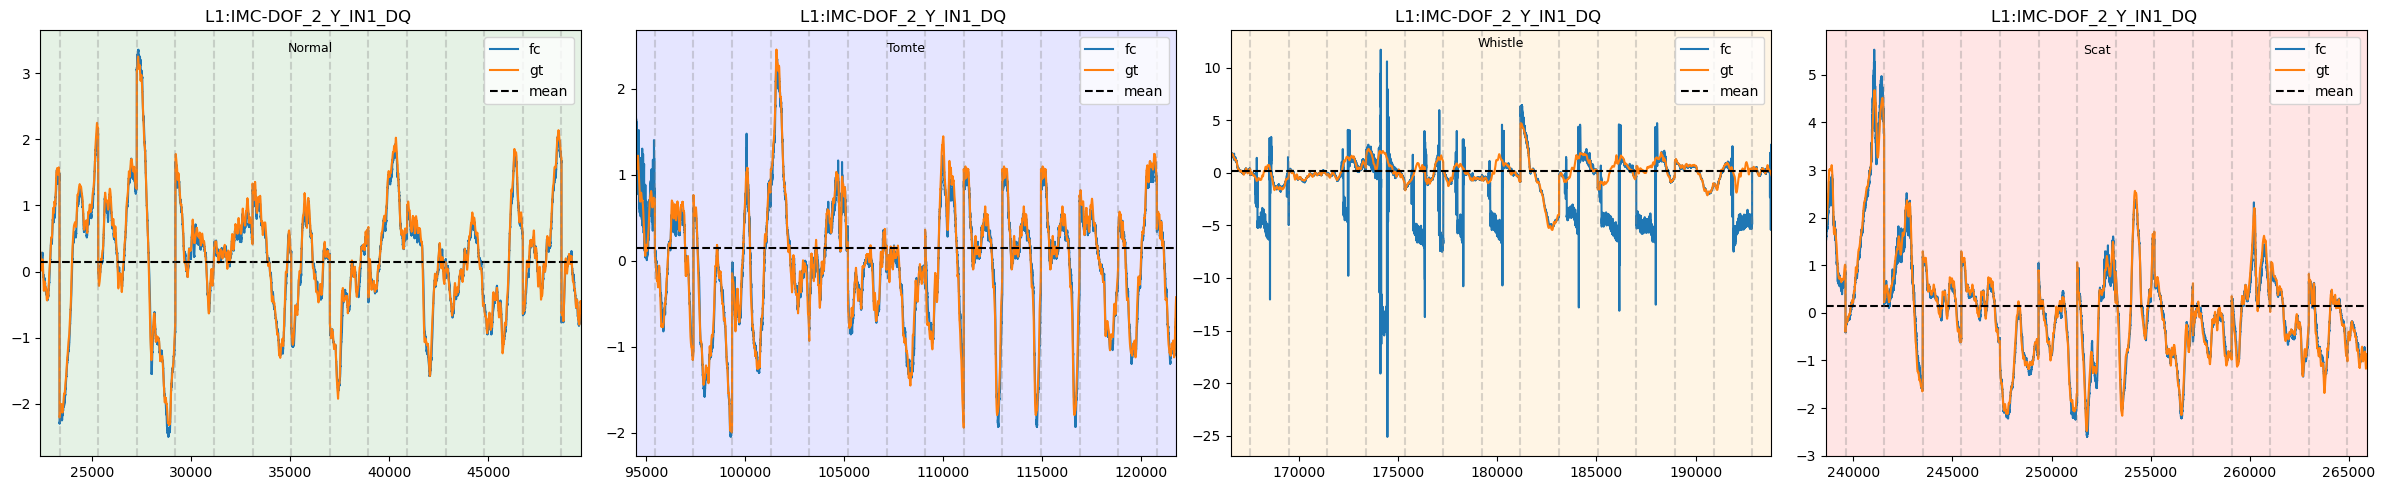

In [ ]:
# Plot samples 1x4
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
data_middles = [ 0.5 * segment_len, 1.5 * segment_len, 2.5 * segment_len, 3.5 * segment_len]
titles = ["Normal", "Tomte", "Whistle", "Scat"]
for ax, dm, title in zip(axes, data_middles, titles):
    draw_plot(ax, data_middle=int(dm), show_len = int(1948*7), id = 3)

plt.tight_layout()
plt.show()

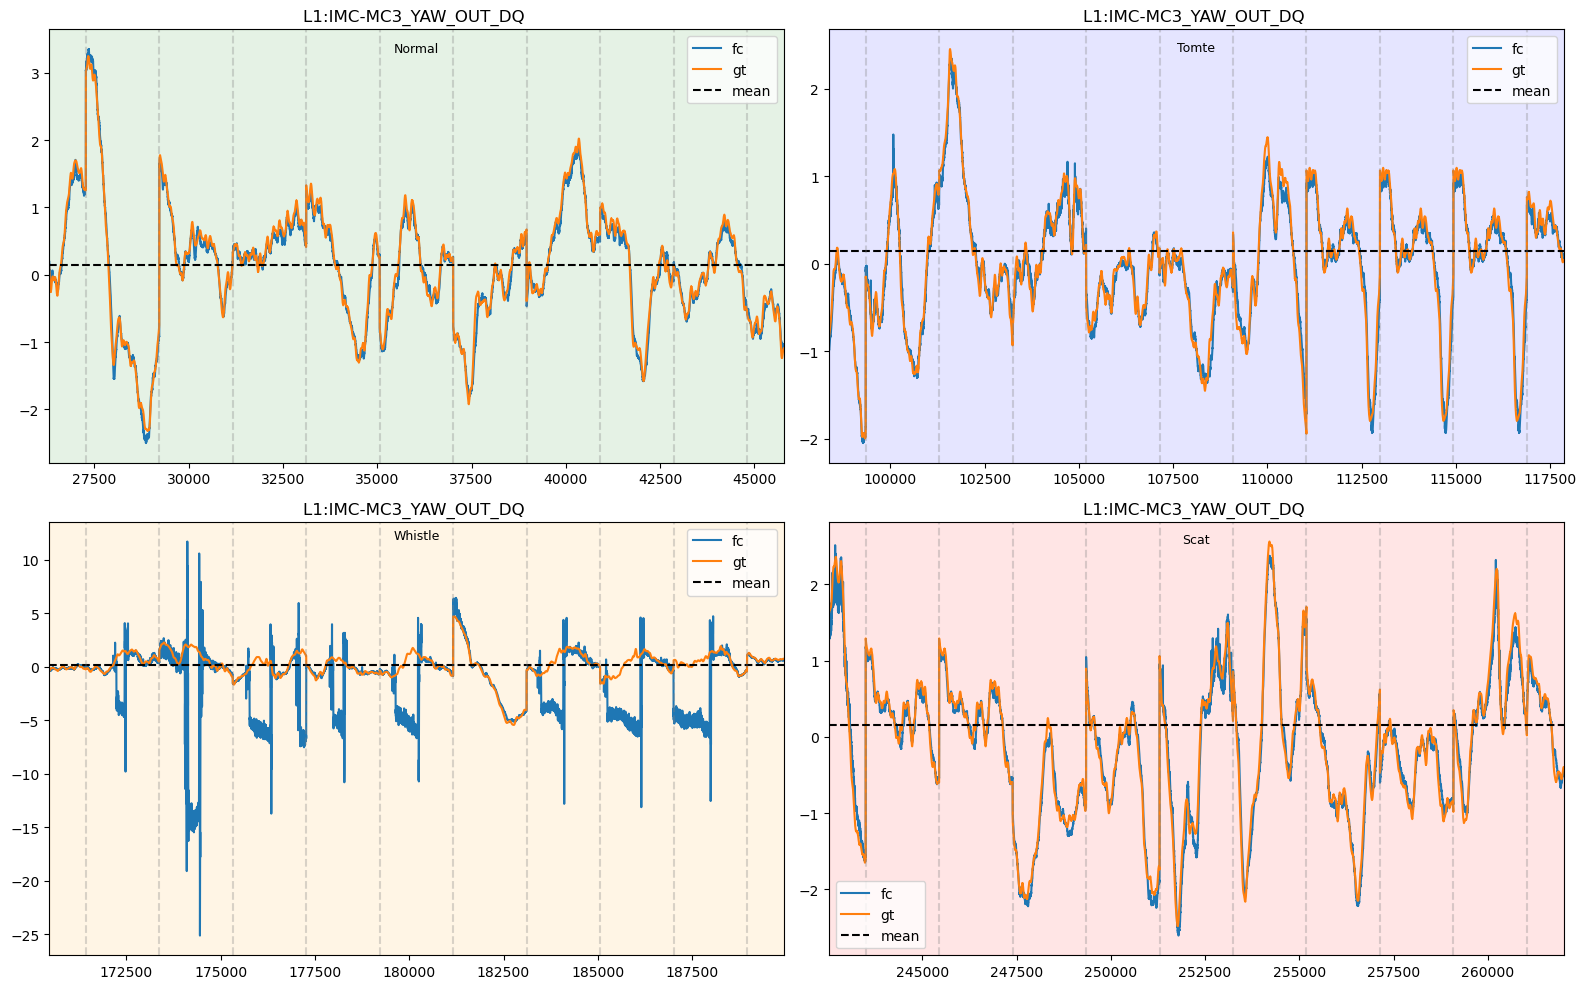

In [ ]:
# Plot samples 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes = axes.flatten()

data_middles = [0.5 * segment_len, 1.5 * segment_len, 2.5 * segment_len, 3.5 * segment_len]

titles = ["Normal", "Tomte", "Whistle", "Scat"]

for ax, dm, title in zip(axes, data_middles, titles):
    draw_plot(ax, data_middle=int(dm), show_len=show_len, id = 22)
plt.tight_layout()
plt.show()